In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

# Load the data
df = pd.read_csv('health_dataset.csv')

print("Dataset shape:", df.shape)
print("\nFirst few rows:")
print(df.head())
print("\nColumn names:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())

Dataset shape: (108252, 50)

First few rows:
   ADM_RNO1  Province  Health_region_ grouped  Gender  Marital_status  \
0      1000        47                   47906       2               1   
1    100005        47                   47906       1               1   
2    100012        59                   59914       2               2   
3    100015        13                   13904       1               2   
4    100018        46                   46903       1               2   

   Household  Age  Worked_job_business  Edu_level  Gen_health_state  ...  \
0          2    3                    1          3                 3  ...   
1          2    5                    6          2                 3  ...   
2          1    5                    6          1                 2  ...   
3          1    5                    6          1                 3  ...   
4          1    4                    2          3                 5  ...   

   Physical_vigorous_act_time  Work_hours   working_status 

Target variable (Stress_level) distribution:
Stress_level
1    18877
2    29387
3    40668
4    16002
5     2786
7      375
8       47
Name: count, dtype: int64

Features shape: (108142, 46)
Target shape: (108142,)


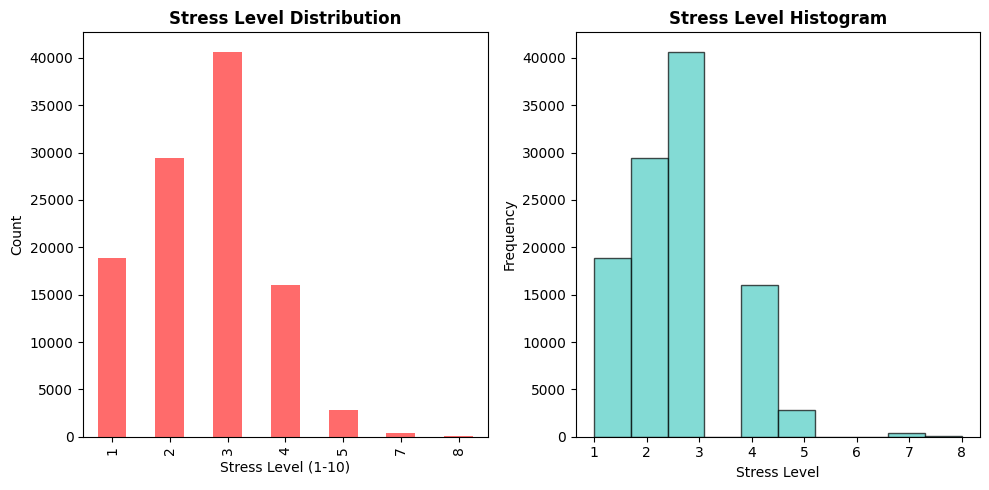

Data visualization complete!


In [3]:
# We'll predict Stress_level based on health and lifestyle factors
# First, let's clean the data and select relevant features

# Drop ID columns and handle missing values
df_clean = df.copy()
df_clean = df_clean.dropna()  # Remove the 110 rows with missing Smoked values

# Select features for the model (exclude target and ID columns)
features_to_drop = ['ADM_RNO1', 'Health_region_ grouped', 'Stress_level', 'Work_hours ']
features_to_keep = [col for col in df_clean.columns if col not in features_to_drop]

X = df_clean[features_to_keep]
y = df_clean['Stress_level']

print(f"Target variable (Stress_level) distribution:")
print(y.value_counts().sort_index())
print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")

# Check the distribution
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
y.value_counts().sort_index().plot(kind='bar', color='#FF6B6B')
plt.title('Stress Level Distribution', fontweight='bold')
plt.xlabel('Stress Level (1-10)')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
plt.hist(y, bins=10, color='#4ECDC4', edgecolor='black', alpha=0.7)
plt.title('Stress Level Histogram', fontweight='bold')
plt.xlabel('Stress Level')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

print("Data visualization complete!")

In [4]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

# Normalize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Random Forest classifier
model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, max_depth=15)
model.fit(X_train_scaled, y_train)

print("Model trained!")

# Make predictions
y_pred = model.predict(X_test_scaled)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"\nModel Accuracy: {accuracy:.2%}")

# Get detailed metrics
print("\n" + "="*60)
print("DETAILED CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_test, y_pred))

Training set: 86513 samples
Test set: 21629 samples
Model trained!

Model Accuracy: 47.03%

DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

           1       0.48      0.31      0.38      3692
           2       0.42      0.40      0.41      5893
           3       0.48      0.68      0.57      8212
           4       0.53      0.31      0.39      3215
           5       0.43      0.02      0.05       534
           7       0.00      0.00      0.00        71
           8       0.00      0.00      0.00        12

    accuracy                           0.47     21629
   macro avg       0.34      0.25      0.26     21629
weighted avg       0.47      0.47      0.45     21629



In [5]:
# Convert to 3-class problem: Low (1-2), Medium (3-5), High (6-8)
def categorize_stress(stress_level):
    if stress_level <= 2:
        return 0  # Low
    elif stress_level <= 5:
        return 1  # Medium
    else:
        return 2  # High

y_simplified = y.apply(categorize_stress)
stress_categories = {0: 'Low Stress', 1: 'Medium Stress', 2: 'High Stress'}

print("Simplified stress distribution:")
print(y_simplified.value_counts().sort_index())

# Split with simplified target
X_train, X_test, y_train_simp, y_test_simp = train_test_split(
    X, y_simplified, test_size=0.2, random_state=42
)

# Normalize
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train model
model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, max_depth=15)
model.fit(X_train_scaled, y_train_simp)

# Predict
y_pred_simp = model.predict(X_test_scaled)
accuracy_simp = accuracy_score(y_test_simp, y_pred_simp)

print(f"\n3-Class Model Accuracy: {accuracy_simp:.2%}")

print("\n" + "="*60)
print("CLASSIFICATION REPORT - 3 STRESS CATEGORIES")
print("="*60)
print(classification_report(y_test_simp, y_pred_simp, target_names=list(stress_categories.values())))

Simplified stress distribution:
Stress_level
0    48264
1    59456
2      422
Name: count, dtype: int64

3-Class Model Accuracy: 71.81%

CLASSIFICATION REPORT - 3 STRESS CATEGORIES
               precision    recall  f1-score   support

   Low Stress       0.67      0.71      0.69      9585
Medium Stress       0.76      0.73      0.74     11961
  High Stress       0.00      0.00      0.00        83

     accuracy                           0.72     21629
    macro avg       0.48      0.48      0.48     21629
 weighted avg       0.72      0.72      0.72     21629



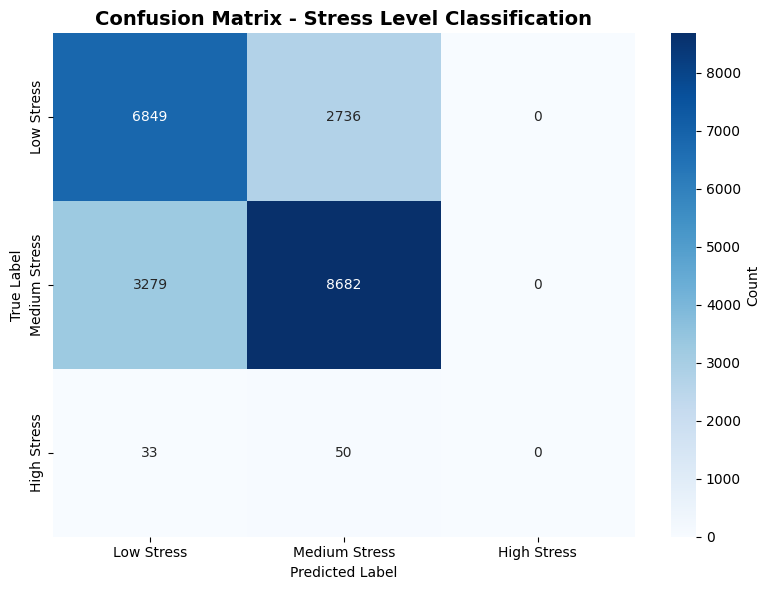


Top 15 Most Important Features for Stress Prediction:
            Feature  Importance
        Work_stress    0.153010
  Life_satisfaction    0.100063
Mental_health_state    0.079952
                Age    0.057777
Worked_job_business    0.048309
    working_status     0.042079
   Gen_health_state    0.034971
      Income_source    0.026576
   Anxiety_disorder    0.024555
       Total_income    0.023028
    Sense_belonging    0.022377
Health_utility_indx    0.022094
      Fruit_veg_con    0.020697
           Province    0.020440
      Mood_disorder    0.017991


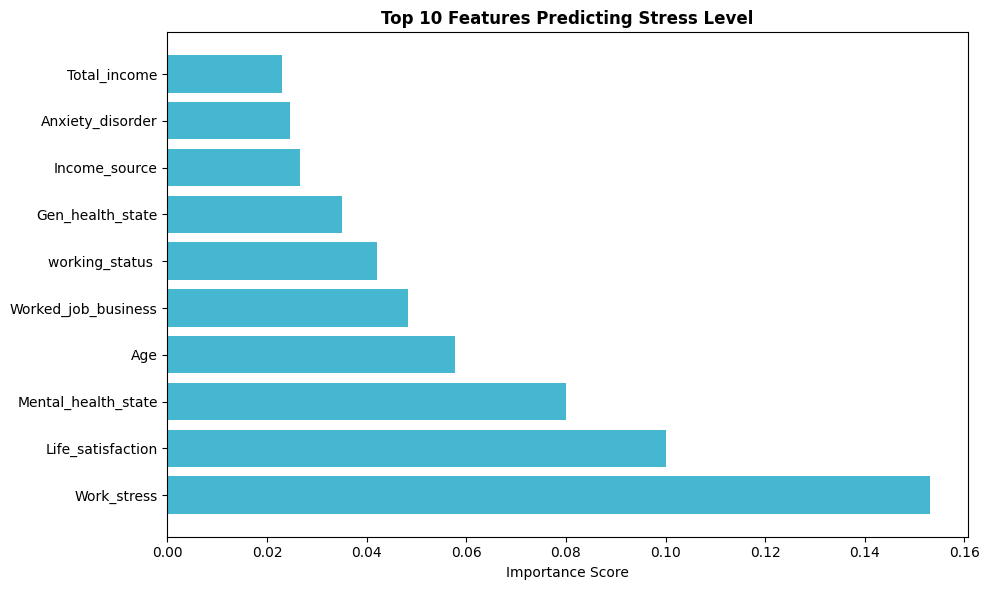


Visualization complete!


In [6]:
# Create confusion matrix visualization
cm = confusion_matrix(y_test_simp, y_pred_simp)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=list(stress_categories.values()), 
            yticklabels=list(stress_categories.values()),
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - Stress Level Classification', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# Feature importance - which factors predict stress?
feature_importance = pd.DataFrame({
    'Feature': features_to_keep,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 15 Most Important Features for Stress Prediction:")
print(feature_importance.head(15).to_string(index=False))

# Visualize top features
plt.figure(figsize=(10, 6))
top_features = feature_importance.head(10)
plt.barh(range(len(top_features)), top_features['Importance'], color='#45B7D1')
plt.yticks(range(len(top_features)), top_features['Feature'])
plt.xlabel('Importance Score')
plt.title('Top 10 Features Predicting Stress Level', fontweight='bold')
plt.tight_layout()
plt.show()

print("\nVisualization complete!")